# Evaluación Formativa 2  
## Modelamiento Predictivo — Weather Dataset Australia

**Curso:** MCDI501: Estadística Computacional para la Toma de Decisiones  
**Programa:** Magíster en Ciencia de Datos e Inteligencia Artificial, UNAB  
**Grupo:** 7  
**Integrantes:** Alana Bermúdez, Gonzalo Mansilla y Eduardo Villalón  
**Dataset:** Weather Dataset Australia (`weatherAUS`)  
**Repositorio:** https://github.com/alanabermudezaballay/mcdi500_s1_grupo7  

## Objetivo del notebook

Este notebook desarrolla la preparación de datos para el modelamiento predictivo de `RainTomorrow`, integrando explícitamente resultados obtenidos en la Sumativa 1 y Sumativa 2. El objetivo es dejar una base reproducible para ajustar posteriormente un modelo de regresión logística, evaluar su desempeño predictivo y preparar la Sumativa 3.

# 1. Preparación de datos para modelamiento

Esta etapa utiliza como base los resultados de las evaluaciones anteriores:

## Resultados relevantes de Sumativa 1

- `Humidity3pm` mostró una diferencia relevante entre los grupos de `RainTomorrow`.
- La media de `Humidity3pm` fue mayor cuando `RainTomorrow = Yes` que cuando `RainTomorrow = No`.
- `RainToday` presentó asociación con `RainTomorrow`.
- `Pressure3pm` y `WindGustSpeed` fueron consideradas variables meteorológicas relevantes.
- La base presentaba valores faltantes, por lo que se trabajó con una estrategia de imputación.

## Resultados relevantes de Sumativa 2

- `Humidity3pm` fue robusta bajo bootstrap, prueba de permutación y análisis sin outliers.
- `Pressure3pm` mostró estabilidad bajo bootstrap y bajo exclusión de outliers.
- `WindGustSpeed` presentó sensibilidad a valores extremos, por lo que debe usarse con cautela.
- La asociación entre `RainToday` y `RainTomorrow` se mantuvo estable en el análisis de robustez.
- Se mantiene la advertencia metodológica de que la imputación por mediana puede reducir artificialmente la variabilidad y estrechar intervalos de confianza.

Con base en estos resultados, se seleccionan inicialmente las siguientes variables predictoras:

- `RainToday`
- `Humidity3pm`
- `Pressure3pm`
- `WindGustSpeed`

La variable objetivo será:

- `RainTomorrow`

In [1]:
# Librerías base
import pandas as pd
import numpy as np
from pathlib import Path

# Configuración general
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42

In [2]:
from pathlib import Path
import pandas as pd

# Rutas candidatas para encontrar el dataset limpio usado en S1/S2
rutas_candidatas = [
    Path("weatherAUS_limpio.csv"),
    Path("S2/weatherAUS_limpio.csv"),
    Path("EstadisticaComputacional/S2/weatherAUS_limpio.csv"),
    Path("../S2/weatherAUS_limpio.csv"),
    Path("../EstadisticaComputacional/S2/weatherAUS_limpio.csv"),
    Path("../../EstadisticaComputacional/S2/weatherAUS_limpio.csv"),
]

ruta_dataset = None

print("Buscando dataset en rutas candidatas:\n")

for ruta in rutas_candidatas:
    print(f"{ruta} -> existe: {ruta.exists()}")
    if ruta.exists():
        ruta_dataset = ruta
        break

if ruta_dataset is None:
    raise FileNotFoundError(
        "No se encontró weatherAUS_limpio.csv. "
        "Revisa si el archivo está en EstadisticaComputacional/S2 o copia el archivo a la carpeta F2."
    )

df = pd.read_csv(ruta_dataset)

print("\nDataset cargado correctamente")
print(f"Ruta usada: {ruta_dataset}")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")

df.head()

Buscando dataset en rutas candidatas:

weatherAUS_limpio.csv -> existe: False
S2\weatherAUS_limpio.csv -> existe: False
EstadisticaComputacional\S2\weatherAUS_limpio.csv -> existe: False
..\S2\weatherAUS_limpio.csv -> existe: True

Dataset cargado correctamente
Ruta usada: ..\S2\weatherAUS_limpio.csv
Filas: 145,460
Columnas: 23


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4000,22.9000,0.6000,4.8000,8.4000,W,44.0000,W,WNW,20.0000,24.0000,71.0000,22.0000,"1,007.7000","1,007.1000",8.0000,5.0000,16.9000,21.8000,No,No
1,2008-12-02,Albury,7.4000,25.1000,0.0000,4.8000,8.4000,WNW,44.0000,NNW,WSW,4.0000,22.0000,44.0000,25.0000,"1,010.6000","1,007.8000",5.0000,5.0000,17.2000,24.3000,No,No
2,2008-12-03,Albury,12.9000,25.7000,0.0000,4.8000,8.4000,WSW,46.0000,W,WSW,19.0000,26.0000,38.0000,30.0000,"1,007.6000","1,008.7000",5.0000,2.0000,21.0000,23.2000,No,No
3,2008-12-04,Albury,9.2000,28.0000,0.0000,4.8000,8.4000,NE,24.0000,SE,E,11.0000,9.0000,45.0000,16.0000,"1,017.6000","1,012.8000",5.0000,5.0000,18.1000,26.5000,No,No
4,2008-12-05,Albury,17.5000,32.3000,1.0000,4.8000,8.4000,W,41.0000,ENE,NW,7.0000,20.0000,82.0000,33.0000,"1,010.8000","1,006.0000",7.0000,8.0000,17.8000,29.7000,No,No


In [3]:
from pathlib import Path
import os

print("Carpeta actual de ejecución:")
print(Path.cwd())

print("\nArchivos/carpetas visibles desde esta ubicación:")
for item in Path.cwd().iterdir():
    print("-", item.name)

Carpeta actual de ejecución:
C:\Python\mcdi500_s1_grupo7\EstadisticaComputacional\F2

Archivos/carpetas visibles desde esta ubicación:
- .ipynb_checkpoints
- datos_preparados
- formativa2_modelamiento_predictivo.ipynb


In [4]:
# Revisión de columnas disponibles
df.columns.tolist()

['Date',
 'Location',
 'MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustDir',
 'WindGustSpeed',
 'WindDir9am',
 'WindDir3pm',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm',
 'RainToday',
 'RainTomorrow']

In [5]:
# Variables requeridas para esta etapa
predictoras = ["RainToday", "Humidity3pm", "Pressure3pm", "WindGustSpeed"]
objetivo = "RainTomorrow"

columnas_requeridas = predictoras + [objetivo]

faltantes_columnas = [col for col in columnas_requeridas if col not in df.columns]

if faltantes_columnas:
    raise ValueError(f"Faltan columnas requeridas en el dataset: {faltantes_columnas}")

print("Todas las columnas requeridas están disponibles:")
print(columnas_requeridas)

Todas las columnas requeridas están disponibles:
['RainToday', 'Humidity3pm', 'Pressure3pm', 'WindGustSpeed', 'RainTomorrow']


In [6]:
# Base reducida para modelamiento
df_modelo = df[columnas_requeridas].copy()

print("Dimensión base de modelamiento:")
print(df_modelo.shape)

df_modelo.head()

Dimensión base de modelamiento:
(145460, 5)


,RainToday,Humidity3pm,Pressure3pm,WindGustSpeed,RainTomorrow
0,No,22.0000,"1,007.1000",44.0000,No
1,No,25.0000,"1,007.8000",44.0000,No
2,No,30.0000,"1,008.7000",46.0000,No
3,No,16.0000,"1,012.8000",24.0000,No
4,No,33.0000,"1,006.0000",41.0000,No


In [7]:
# Revisión de valores faltantes antes del tratamiento
faltantes = df_modelo.isna().sum().to_frame("faltantes")
faltantes["porcentaje"] = (faltantes["faltantes"] / len(df_modelo) * 100).round(2)

faltantes

,faltantes,porcentaje
RainToday,0,0.0000
Humidity3pm,0,0.0000
Pressure3pm,0,0.0000
WindGustSpeed,0,0.0000
RainTomorrow,0,0.0000


In [8]:
# Conversión robusta de variables binarias Yes/No a 1/0

def convertir_binaria_robusta(serie):
    """
    Convierte variables binarias tipo Yes/No, yes/no, 1/0 a valores 1/0.
    Mantiene NaN cuando no existe valor.
    """
    s = serie.astype("string").str.strip().str.lower()
    
    return s.map({
        "yes": 1,
        "no": 0,
        "1": 1,
        "0": 0
    })

df_modelo["RainToday"] = convertir_binaria_robusta(df_modelo["RainToday"])
df_modelo["RainTomorrow"] = convertir_binaria_robusta(df_modelo["RainTomorrow"])

print("Valores únicos RainToday después de conversión:")
print(df_modelo["RainToday"].value_counts(dropna=False))

print("\nValores únicos RainTomorrow después de conversión:")
print(df_modelo["RainTomorrow"].value_counts(dropna=False))

Valores únicos RainToday después de conversión:
RainToday
0    113580
1     31880
Name: count, dtype: int64

Valores únicos RainTomorrow después de conversión:
RainTomorrow
0    113583
1     31877
Name: count, dtype: int64


## Tratamiento de valores faltantes

Se aplica imputación simple para mantener la mayor cantidad posible de observaciones. Las variables numéricas se imputan con la mediana, criterio consistente con las etapas previas y más robusto frente a valores extremos. La variable binaria `RainToday` se imputa con la moda si existieran valores faltantes.

La variable objetivo `RainTomorrow` no se imputa; si existieran registros sin objetivo, se eliminan para evitar introducir etiquetas artificiales.

In [9]:
# Imputación simple
variables_numericas = ["Humidity3pm", "Pressure3pm", "WindGustSpeed"]
variables_binarias = ["RainToday"]

# Imputación de variables numéricas con mediana
for col in variables_numericas:
    mediana = df_modelo[col].median()
    df_modelo[col] = df_modelo[col].fillna(mediana)
    print(f"{col}: imputado con mediana = {mediana:.4f}")

# Imputación de variable binaria con moda
for col in variables_binarias:
    moda = df_modelo[col].mode(dropna=True)[0]
    df_modelo[col] = df_modelo[col].fillna(moda)
    print(f"{col}: imputado con moda = {moda}")

# Eliminar registros sin variable objetivo
filas_antes = len(df_modelo)
df_modelo = df_modelo.dropna(subset=["RainTomorrow"])
filas_despues = len(df_modelo)

print(f"\nFilas eliminadas por objetivo faltante: {filas_antes - filas_despues}")
print(f"Dimensión final base modelamiento: {df_modelo.shape}")

Humidity3pm: imputado con mediana = 52.0000
Pressure3pm: imputado con mediana = 1015.2000
WindGustSpeed: imputado con mediana = 39.0000
RainToday: imputado con moda = 0

Filas eliminadas por objetivo faltante: 0
Dimensión final base modelamiento: (145460, 5)


In [10]:
# Confirmación de faltantes después del tratamiento
df_modelo.isna().sum()

RainToday        0
Humidity3pm      0
Pressure3pm      0
WindGustSpeed    0
RainTomorrow     0
dtype: int64

In [11]:
# Separación de variables predictoras y objetivo
X = df_modelo[predictoras].copy()
y = df_modelo[objetivo].copy().astype("int64")

print("Dimensión X:", X.shape)
print("Dimensión y:", y.shape)

print("\nDistribución de la variable objetivo:")
print(y.value_counts(normalize=True).rename("proporción"))

print("\nConteo absoluto de la variable objetivo:")
print(y.value_counts())

Dimensión X: (145460, 4)
Dimensión y: (145460,)

Distribución de la variable objetivo:
RainTomorrow
0   0.7809
1   0.2191
Name: proporción, dtype: float64

Conteo absoluto de la variable objetivo:
RainTomorrow
0    113583
1     31877
Name: count, dtype: int64


## División train/test

Se divide la base en entrenamiento y prueba usando una proporción 70/30. Para conservar la proporción de la variable objetivo `RainTomorrow`, la partición se realiza de forma estratificada manualmente, separando los índices de cada clase antes de seleccionar entrenamiento y prueba.

In [12]:
# División train/test 70/30 estratificada sin scikit-learn

rng = np.random.default_rng(RANDOM_STATE)

train_indices = []
test_indices = []

for clase in sorted(y.unique()):
    # Se usa .copy() para evitar error de arreglo read-only
    indices_clase = y[y == clase].index.to_numpy().copy()
    rng.shuffle(indices_clase)
    
    n_test = int(round(len(indices_clase) * 0.30))
    
    test_indices.extend(indices_clase[:n_test])
    train_indices.extend(indices_clase[n_test:])

train_indices = np.array(train_indices)
test_indices = np.array(test_indices)

X_train = X.loc[train_indices].copy()
X_test = X.loc[test_indices].copy()
y_train = y.loc[train_indices].copy()
y_test = y.loc[test_indices].copy()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nDistribución objetivo en entrenamiento:")
print(y_train.value_counts(normalize=True).rename("proporción"))

print("\nDistribución objetivo en prueba:")
print(y_test.value_counts(normalize=True).rename("proporción"))

X_train: (101822, 4)
X_test : (43638, 4)
y_train: (101822,)
y_test : (43638,)

Distribución objetivo en entrenamiento:
RainTomorrow
0   0.7809
1   0.2191
Name: proporción, dtype: float64

Distribución objetivo en prueba:
RainTomorrow
0   0.7809
1   0.2191
Name: proporción, dtype: float64


## Estandarización de variables numéricas

Las variables continuas `Humidity3pm`, `Pressure3pm` y `WindGustSpeed` se estandarizan usando la media y desviación estándar calculadas solo sobre el conjunto de entrenamiento. Luego, esos mismos parámetros se aplican al conjunto de prueba.

Este procedimiento evita fuga de información desde el conjunto de prueba hacia el entrenamiento. La variable `RainToday` no se estandariza porque ya está codificada como binaria 0/1.

In [13]:
# Estandarización manual de variables numéricas

variables_numericas = ["Humidity3pm", "Pressure3pm", "WindGustSpeed"]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Parámetros calculados solo con entrenamiento
medias_train = X_train[variables_numericas].mean()
desvios_train = X_train[variables_numericas].std(ddof=0)

# Evitar división por cero
desvios_train = desvios_train.replace(0, 1)

# Aplicar estandarización
X_train_scaled[variables_numericas] = (
    X_train[variables_numericas] - medias_train
) / desvios_train

X_test_scaled[variables_numericas] = (
    X_test[variables_numericas] - medias_train
) / desvios_train

print("Medias usadas para estandarizar:")
print(medias_train)

print("\nDesviaciones estándar usadas para estandarizar:")
print(desvios_train)

print("\nResumen de X_train_scaled:")
X_train_scaled.describe().T

Medias usadas para estandarizar:
Humidity3pm        51.5715
Pressure3pm     1,015.2472
WindGustSpeed      39.9697
dtype: float64

Desviaciones estándar usadas para estandarizar:
Humidity3pm     20.4708
Pressure3pm      6.6674
WindGustSpeed   13.1611
dtype: float64

Resumen de X_train_scaled:


,count,mean,std,min,25%,50%,75%,max
RainToday,"101,822.0000",0.2193,0.4138,0.0000,0.0000,0.0000,0.0000,1.0000
Humidity3pm,"101,822.0000",0.0000,1.0000,-2.5193,-0.7118,0.0209,0.6560,2.3657
Pressure3pm,"101,822.0000",0.0000,1.0000,-5.7214,-0.6370,-0.0071,0.6228,3.6525
WindGustSpeed,"101,822.0000",-0.0000,1.0000,-2.5811,-0.6815,-0.0737,0.4582,7.2205


In [14]:
# Guardar archivos preparados para trazabilidad y uso posterior

salida_dir = Path("datos_preparados")
salida_dir.mkdir(exist_ok=True)

X_train_scaled.to_csv(salida_dir / "X_train_scaled.csv", index=False)
X_test_scaled.to_csv(salida_dir / "X_test_scaled.csv", index=False)
y_train.to_csv(salida_dir / "y_train.csv", index=False)
y_test.to_csv(salida_dir / "y_test.csv", index=False)

# Guardar parámetros de estandarización usados sobre el conjunto de entrenamiento
parametros_estandarizacion = pd.DataFrame({
    "media_train": medias_train,
    "desvio_train": desvios_train
})

parametros_estandarizacion.to_csv(
    salida_dir / "parametros_estandarizacion.csv",
    index=True
)

print("Archivos guardados en carpeta:", salida_dir)
print("Archivos generados:")
for archivo in salida_dir.iterdir():
    print("-", archivo.name)

Archivos guardados en carpeta: datos_preparados
Archivos generados:
- parametros_estandarizacion.csv
- X_test_scaled.csv
- X_train_scaled.csv
- y_test.csv
- y_train.csv


## Cierre de preparación de datos

La base de modelamiento quedó preparada para ajustar un modelo de regresión logística orientado a predecir `RainTomorrow`.

Se utilizaron cuatro variables predictoras seleccionadas desde los resultados previos de S1 y S2:

- `RainToday`, por su asociación robusta con `RainTomorrow`.
- `Humidity3pm`, por su diferencia significativa y robusta entre días con y sin lluvia futura.
- `Pressure3pm`, por su estabilidad bajo bootstrap y análisis de robustez.
- `WindGustSpeed`, por su relevancia meteorológica, aunque documentando su sensibilidad a outliers.

La base fue dividida en entrenamiento y prueba en proporción 70/30, con estratificación por la variable objetivo. Las variables numéricas fueron estandarizadas usando únicamente los parámetros del conjunto de entrenamiento, evitando fuga de información hacia el conjunto de prueba.

Los objetos `X_train_scaled`, `X_test_scaled`, `y_train` y `y_test` quedan disponibles para la etapa siguiente de ajuste del modelo de regresión logística. Además, se guardaron archivos `.csv` en la carpeta `datos_preparados` para asegurar trazabilidad y facilitar el trabajo colaborativo.

# 2. Modelo de Regresión Logística

En esta etapa, procedemos al ajuste de un modelo de regresión logística para predecir la variable objetivo `RainTomorrow`. La selección de variables (`RainToday`, `Humidity3pm`, `Pressure3pm`, `WindGustSpeed`) se fundamenta en los análisis de robustez y correlación realizados en S1 y S2. El objetivo es identificar la significancia estadística de los predictores y evaluar la ausencia de multicolinealidad mediante el factor `VIF`.

In [15]:
import statsmodels.api as sm
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_train_sm = sm.add_constant(X_train_scaled)
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()

print(result.summary())
print("\n--- Odds Ratios ---")
print(np.exp(result.params))

vif_data = pd.DataFrame()
vif_data["feature"] = X_train_sm.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_sm.values, i) for i in range(len(X_train_sm.columns))]
print("\n--- Valores VIF ---")
print(vif_data)

Optimization terminated successfully.
         Current function value: 0.376358
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:           RainTomorrow   No. Observations:               101822
Model:                          Logit   Df Residuals:                   101817
Method:                           MLE   Df Model:                            4
Date:                Wed, 08 Jul 2026   Pseudo R-squ.:                  0.2843
Time:                        23:53:39   Log-Likelihood:                -38321.
converged:                       True   LL-Null:                       -53541.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.9349      0.012   -159.106      0.000      -1.959      -1.911
RainToday         0.

### 2.1 Interpretación de resultados

El modelo ajustado presenta una significancia estadística global robusta, con todos los predictores mostrando valores `P > |z|` de `0.000`. Los valores de `VIF` obtenidos son inferiores al umbral crítico de `5`, lo que confirma la ausencia de multicolinealidad significativa y garantiza la estabilidad de los coeficientes estimados.

En cuanto a la influencia de las variables, los `Odds Ratios` revelan hallazgos clave:
* `RainToday`: Presenta un `Odds Ratio` de aproximadamente `1.91`, lo que implica que si llueve hoy, la probabilidad de lluvia para `RainTomorrow` aumenta casi al doble, manteniendo las demás variables constantes.
* `Humidity3pm`: Posee una influencia positiva marcada, donde cada incremento unitario en la humedad aumenta significativamente la probabilidad de precipitación.
* `Pressure3pm`: Presenta un coeficiente negativo, actuando como un factor protector o inhibidor de la probabilidad de lluvia.
* `WindGustSpeed`: Muestra un impacto positivo moderado, contribuyendo incrementalmente a la probabilidad de lluvia.

Estos resultados validan la solidez del modelo para la fase predictiva, permitiendo una interpretación clara de los factores meteorológicos que condicionan la precipitación.

# 3. Evaluación de desempeño predictivo

En esta sección, se procede a evaluar la capacidad predictiva del modelo utilizando el conjunto de prueba `X_test`. El objetivo es calcular métricas de desempeño (como `Accuracy` y `Precision`) para validar la calidad del modelo.

## 3.1 Generación de predicciones

Una vez ajustado el modelo de regresión logística, se generan predicciones utilizando el conjunto de prueba (`X_test`). Este conjunto contiene observaciones que no fueron utilizadas durante el entrenamiento, permitiendo evaluar la capacidad de generalización del modelo.

Se generan dos tipos de resultados:

- `y_prob`: probabilidades estimadas de que ocurra lluvia al día siguiente (`RainTomorrow = 1`).
- `y_pred`: clasificación final obtenida a partir de las probabilidades, utilizando un umbral de decisión de 0.5.

Estas predicciones constituyen la base para la evaluación del desempeño predictivo mediante métricas de clasificación y curvas de discriminación.

In [16]:
# ==========================================
# Generación de predicciones
# ==========================================

# Agregar constante al conjunto de prueba escalado
X_test_sm = sm.add_constant(X_test_scaled)

# Probabilidades estimadas de lluvia
y_prob = result.predict(X_test_sm)

# Conversión de probabilidades a clases
y_pred = (y_prob >= 0.5).astype(int)

# Mostrar resumen
print("Resumen estadístico de probabilidades")
print(y_prob.describe())

print("\nPrimeras observaciones clasificadas")
print(y_pred.head())

Resumen estadístico de probabilidades
count   43,638.0000
mean         0.2183
std          0.2307
min          0.0035
25%          0.0486
50%          0.1259
75%          0.3032
max          0.9923
dtype: float64

Primeras observaciones clasificadas
41419     0
122973    0
113996    0
143982    0
53975     1
dtype: int64


## 3.2 Matriz de confusión

La matriz de confusión permite comparar las predicciones generadas por el modelo con los valores reales observados en el conjunto de prueba.

Esta herramienta resume la capacidad predictiva del modelo mediante cuatro posibles resultados:

- Verdaderos Positivos (VP): el modelo predice lluvia y efectivamente ocurre lluvia.
- Verdaderos Negativos (VN): el modelo predice ausencia de lluvia y efectivamente no ocurre lluvia.
- Falsos Positivos (FP): el modelo predice lluvia, pero finalmente no llueve.
- Falsos Negativos (FN): el modelo predice ausencia de lluvia, pero finalmente sí ocurre lluvia.

Estos resultados permiten evaluar de forma más detallada el desempeño del modelo antes de calcular métricas como Accuracy, Precision, Recall y F1 Score.

In [17]:
# ==========================================
# Matriz de confusión
# ==========================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Construcción de la matriz de confusión

cm = confusion_matrix(y_test, y_pred)

# Mostrar matriz numérica

print("Matriz de confusión:")
print(cm)

Matriz de confusión:
[[32286  1789]
 [ 5382  4181]]


### Interpretación de la matriz de confusión

Los resultados obtenidos muestran que el modelo clasificó correctamente 32.286 observaciones donde no ocurrió lluvia (Verdaderos Negativos) y 4.181 observaciones donde efectivamente ocurrió lluvia (Verdaderos Positivos).

Asimismo, se identificaron 1.789 Falsos Positivos, correspondientes a días donde el modelo predijo lluvia pero finalmente no se registraron precipitaciones.

Por otra parte, se observaron 5.382 Falsos Negativos, es decir, días en los que sí ocurrió lluvia, pero el modelo no logró anticiparla.

En términos generales, el modelo presenta una buena capacidad para identificar días sin lluvia, aunque muestra mayores dificultades para detectar todos los eventos de precipitación. Este comportamiento es habitual en problemas donde la clase positiva (lluvia) posee una frecuencia menor que la clase negativa (ausencia de lluvia).

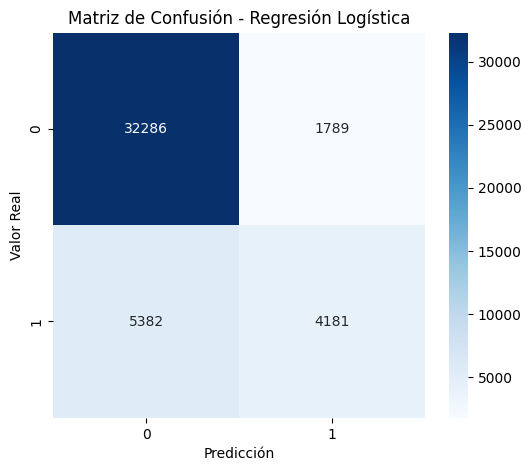

In [18]:
# ==========================================
# Visualización de la matriz de confusión
# ==========================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')

plt.show()

## 3.3 Métricas de desempeño

La matriz de confusión proporciona una visión detallada de los aciertos y errores del modelo. Sin embargo, para resumir cuantitativamente su capacidad predictiva se calculan distintas métricas de clasificación.

En este estudio se utilizarán las siguientes métricas:

- Accuracy
- Precision
- Recall
- F1 Score

Estas métricas permitirán evaluar la capacidad del modelo para predecir correctamente la ocurrencia de lluvia (`RainTomorrow`) en observaciones no utilizadas durante el entrenamiento.

In [19]:
# ==========================================
# Métricas de desempeño
# ==========================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Cálculo de métricas

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Mostrar resultados

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.8357
Precision: 0.7003
Recall: 0.4372
F1 Score: 0.5383


In [20]:
metricas = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

for nombre, valor in metricas.items():
    print(f"{nombre}: {valor:.2%}")

Accuracy: 83.57%
Precision: 70.03%
Recall: 43.72%
F1 Score: 53.83%


### Interpretación de las métricas

#### Accuracy

El modelo obtuvo una exactitud (Accuracy) de 83,57%, lo que indica que aproximadamente ocho de cada diez observaciones fueron clasificadas correctamente. Este resultado sugiere un buen desempeño general para distinguir entre días con y sin lluvia en el conjunto de prueba.

#### Precision

La precisión (Precision) alcanzó un valor de 70,03%. Esto significa que, cuando el modelo predice que lloverá al día siguiente, acierta aproximadamente siete de cada diez veces. Desde una perspectiva operativa, esta métrica indica que las alertas de lluvia generadas por el modelo poseen un nivel de confiabilidad razonablemente alto.

#### Recall

El Recall obtenido fue de 43,72%, lo que indica que el modelo logra detectar menos de la mitad de los eventos reales de lluvia. En consecuencia, una proporción importante de días lluviosos no es identificada correctamente, generando falsos negativos.

#### F1 Score

El F1 Score alcanzó un valor de 53,83%. Esta métrica combina Precision y Recall en una sola medida, reflejando un desempeño intermedio. El resultado indica que el modelo presenta una capacidad moderada para detectar eventos de lluvia, aunque aún existe espacio de mejora en la sensibilidad hacia la clase positiva.

## 3.4 Curva ROC y Área Bajo la Curva (AUC)

Además de las métricas de clasificación tradicionales, es importante evaluar la capacidad discriminante del modelo mediante la Curva ROC (Receiver Operating Characteristic).

La Curva ROC compara la tasa de verdaderos positivos (True Positive Rate) con la tasa de falsos positivos (False Positive Rate) para distintos umbrales de clasificación.

Por su parte, el Área Bajo la Curva (AUC) resume en un único indicador la capacidad del modelo para diferenciar correctamente entre días con lluvia y días sin lluvia.

Mientras más cercano a 1 sea el valor de AUC, mejor será la capacidad predictiva del modelo. Un valor cercano a 0.5 indica un comportamiento similar al azar.

In [21]:
# ==========================================
# Curva ROC y cálculo de AUC
# ==========================================

from sklearn.metrics import roc_curve, roc_auc_score

# Cálculo de la curva ROC

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Cálculo del AUC

auc = roc_auc_score(y_test, y_prob)

print(f"AUC: {auc:.4f}")

AUC: 0.8377


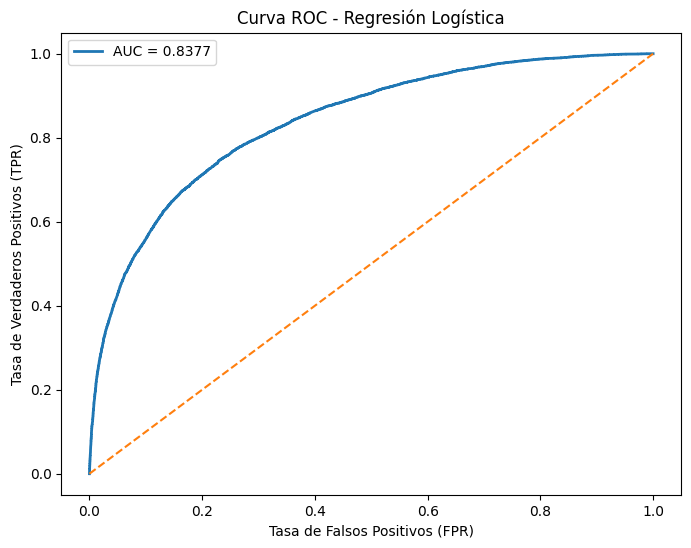

In [22]:
# ==========================================
# Gráfico Curva ROC
# ==========================================

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {auc:.4f}',
    linewidth=2
)

# Línea de referencia (azar)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Regresión Logística')
plt.legend()

plt.show()

### Interpretación de la Curva ROC y AUC

El modelo obtuvo un Área Bajo la Curva (AUC) de 0,8377, lo que indica una buena capacidad para diferenciar entre días con lluvia y días sin lluvia.

En términos prácticos, el resultado sugiere que existe aproximadamente un 83,77% de probabilidad de que el modelo asigne una puntuación más alta a un día que efectivamente presentará lluvia en comparación con un día donde no ocurrirá precipitación.

La Curva ROC se mantiene claramente por encima de la diagonal de referencia correspondiente a una clasificación aleatoria, evidenciando que el modelo posee capacidad discriminante significativa.

Por consiguiente, los resultados obtenidos permiten concluir que la regresión logística construida presenta un desempeño predictivo adecuado para la predicción de la variable RainTomorrow en el conjunto de datos Weather Australia.

## 3.5 Interpretación general del modelo

El modelo de Regresión Logística desarrollado para predecir la variable **RainTomorrow** presenta un desempeño predictivo satisfactorio considerando la complejidad inherente de los fenómenos meteorológicos.

Los resultados obtenidos muestran una exactitud global de 83,57% y un valor de AUC de 0,8377, indicando una buena capacidad para diferenciar entre días con lluvia y días sin lluvia. Desde una perspectiva predictiva, estos indicadores sugieren que el modelo captura adecuadamente los patrones principales asociados a la ocurrencia de precipitaciones.

Entre las principales fortalezas del modelo destaca su capacidad para identificar correctamente los días sin lluvia, evidenciada por la elevada cantidad de Verdaderos Negativos observados en la matriz de confusión. Asimismo, la precisión de 70,03% indica que las alertas de lluvia generadas por el modelo presentan un nivel de confiabilidad relativamente alto.

Sin embargo, el modelo también presenta limitaciones relevantes. El Recall de 43,72% muestra que una proporción importante de los eventos reales de lluvia no es detectada oportunamente, generando Falsos Negativos. Este comportamiento sugiere que el modelo tiende a ser conservador en la clasificación de la clase positiva.

Respecto de las variables explicativas, los resultados obtenidos previamente mediante los coeficientes de regresión, Odds Ratios y análisis de significancia indican que variables como **Humidity3pm**, **RainToday**, **Pressure3pm** y **WindGustSpeed** aportan información relevante para explicar la probabilidad de lluvia al día siguiente. Estos hallazgos son consistentes con los análisis exploratorios realizados en etapas previas del proyecto.

Finalmente, aunque el modelo presenta un desempeño adecuado para fines predictivos, aún existen oportunidades de mejora mediante la incorporación de nuevas variables meteorológicas, técnicas de balanceo de clases o algoritmos más complejos que puedan capturar relaciones no lineales presentes en los datos.

# 4. Síntesis y reflexión final

El presente trabajo integró los resultados obtenidos en las distintas etapas del curso de Estadística Computacional para la Toma de Decisiones, permitiendo construir y evaluar un modelo predictivo orientado a anticipar la ocurrencia de lluvia mediante la variable objetivo **RainTomorrow**.

Los análisis desarrollados durante la Sumativa 1 permitieron comprender el comportamiento general de los datos mediante estadística descriptiva y pruebas de hipótesis. Estos resultados evidenciaron asociaciones relevantes entre distintas variables meteorológicas y la ocurrencia de precipitaciones.

Posteriormente, en la Sumativa 2 se incorporaron metodologías de inferencia computacional, incluyendo técnicas de Bootstrap, Permutación y Simulación Monte Carlo. Estas herramientas permitieron evaluar la estabilidad de las estimaciones, validar relaciones observadas en los datos y cuantificar la incertidumbre asociada a los resultados obtenidos.

El análisis de robustez realizado en etapas previas contribuyó además a identificar las variables con mayor capacidad explicativa, destacando particularmente **RainToday**, **Humidity3pm**, **Pressure3pm** y **WindGustSpeed**, las cuales fueron posteriormente incorporadas en el modelo predictivo de Regresión Logística.

Los resultados obtenidos durante esta Formativa 2 demuestran que la Regresión Logística constituye una herramienta adecuada para modelar la ocurrencia de lluvia. El modelo alcanzó una exactitud de 83,57% y un AUC de 0,8377, evidenciando una capacidad discriminante satisfactoria para diferenciar entre días con lluvia y días sin lluvia.

No obstante, el análisis también permitió identificar oportunidades de mejora, particularmente en la capacidad del modelo para detectar todos los eventos reales de precipitación, reflejada en un Recall de 43,72%. Este hallazgo sugiere la conveniencia de explorar metodologías complementarias en futuras etapas.

Como proyección para la Sumativa 3, se recomienda evaluar modelos alternativos de aprendizaje automático, tales como Random Forest, Gradient Boosting o XGBoost, comparar su desempeño predictivo con la Regresión Logística y analizar estrategias de balanceo de clases que permitan mejorar la detección de eventos de lluvia.

En conclusión, el desarrollo integrado de análisis exploratorio, inferencia computacional y modelamiento predictivo permitió construir una solución estadísticamente fundamentada para la predicción de lluvia, demostrando la utilidad de las técnicas de ciencia de datos para apoyar procesos de toma de decisiones basados en evidencia.